### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

### Import the Folders - Train, Test & Validation

In [2]:
train = tf.keras.utils.image_dataset_from_directory('Fruits_Vegetables/train',
                                                   shuffle=True,
                                                   image_size=(180,180),
                                                   batch_size=32,
                                                   validation_split=False)

Found 3115 files belonging to 36 classes.


In [3]:
cat = train.class_names # categories
print(cat)

['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [4]:
test = tf.keras.utils.image_dataset_from_directory('Fruits_Vegetables/test',
                                                   shuffle=False,
                                                   image_size=(180,180),
                                                   batch_size=32,
                                                   validation_split=False)

Found 359 files belonging to 36 classes.


In [5]:
val = tf.keras.utils.image_dataset_from_directory('Fruits_Vegetables/validation',
                                                   shuffle=False,
                                                   image_size=(180,180),
                                                   batch_size=32,
                                                   validation_split=False)

Found 351 files belonging to 36 classes.


### Visualization

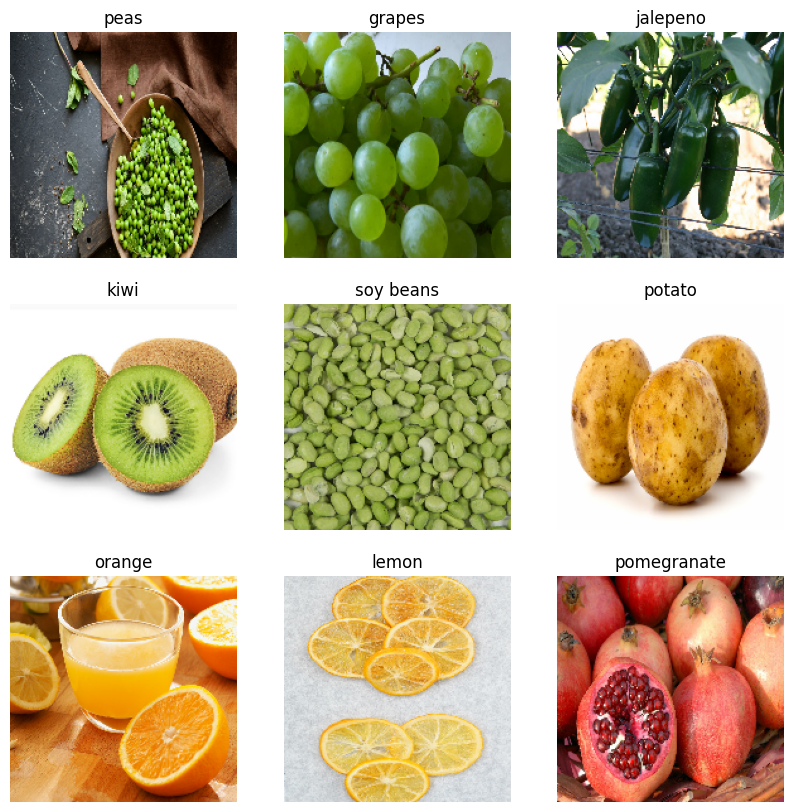

In [6]:
plt.figure(figsize=(10,10))
for image, labels in train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8')) # unknown int
        plt.title(cat[labels[i]])
        plt.axis('off')

## Model

In [7]:
model = Sequential([            # All images are in the form of RGB (Red,Green,Blue)
    layers.Rescaling(1/255),    # 255 combinations for each color
    layers.Conv2D(filters=16, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(units= len(cat))
])

In [8]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [9]:
history = model.fit(train, validation_data=val, epochs=30)

Epoch 1/30
98/98 [==============================] - 56s 541ms/step - loss: 3.2349 - accuracy: 0.1339 - val_loss: 2.2733 - val_accuracy: 0.3590
Epoch 2/30
98/98 [==============================] - 60s 585ms/step - loss: 2.2932 - accuracy: 0.3429 - val_loss: 1.4051 - val_accuracy: 0.6667
Epoch 3/30
98/98 [==============================] - 61s 591ms/step - loss: 1.6823 - accuracy: 0.5149 - val_loss: 0.7723 - val_accuracy: 0.8291
Epoch 4/30
98/98 [==============================] - 58s 571ms/step - loss: 0.9966 - accuracy: 0.7201 - val_loss: 0.4341 - val_accuracy: 0.9117
Epoch 5/30
98/98 [==============================] - 60s 587ms/step - loss: 0.4856 - accuracy: 0.8661 - val_loss: 0.3084 - val_accuracy: 0.9459
Epoch 6/30
98/98 [==============================] - 62s 606ms/step - loss: 0.2600 - accuracy: 0.9297 - val_loss: 0.2921 - val_accuracy: 0.9601
Epoch 7/30
98/98 [==============================] - 61s 596ms/step - loss: 0.1848 - accuracy: 0.9563 - val_loss: 0.3465 - val_accuracy: 0.9487

### Visualizing the Accuracy over Iterations

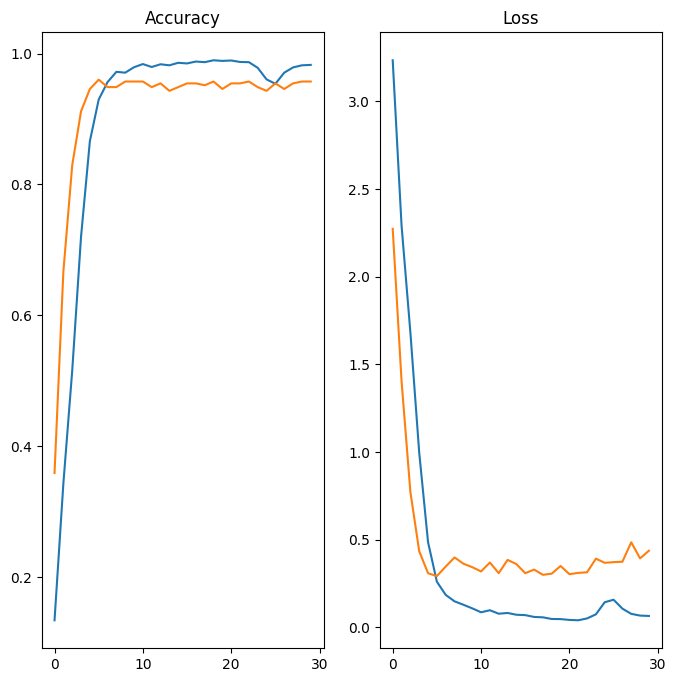

In [10]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(30), history.history['accuracy'],label='Training Accuracy')
plt.plot(range(30), history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(range(30), history.history['loss'],label='Training Loss')
plt.plot(range(30), history.history['val_loss'],label='Validation Loss')
plt.title('Loss')
plt.show()

### Prediction

In [11]:
image = tf.keras.utils.load_img('Image1.jpg',target_size=(180,180))
ima_arr = tf.keras.utils.array_to_img(image)
img_bat = tf.expand_dims(ima_arr,0)

In [12]:
pred = model.predict(img_bat)

1/1 [==============================] - 0s 312ms/step


In [13]:
score = tf.nn.softmax(pred)

In [14]:
print('Veg/Fruit in image is {} with accuracy of {:1.2F}'.format(cat[np.argmax(score)],np.max(score)*100))

Veg/Fruit in image is apple with accuracy of 99.97


In [15]:
model.save("Image_classification_model.h5", include_optimizer=False)

c:\Users\abish\anaconda3\envs\FruitImageClass\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
